In [24]:
from alerce.core import Alerce
import pandas as pd
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

In [59]:
sn1a = Table.read("SNIa_test.ecsv")
snII = Table.read("SNII_test.ecsv")

# time = sn1a["mjd"]
# mag = sn1a["mag"]
# error = sn1a["error"]

# for name, stype, time, mag, error in zip(sn1a["object"], sn1a["type"], sn1a["mjd"], sn1a["mag"], sn1a["error"]):
#     plt.plot(time, mag, color='r')
#     plt.fill_between(time, mag - error, mag + error, interpolate=True)
#     plt.title(f"Object: {name}; Type: {stype}")
#     plt.show()

In [65]:
#machine it
rises = []
falls = []
peaks = []
label = []
for stype, peak, rise, fall in zip(sn1a["type"], sn1a["peak"], sn1a["rise"], sn1a["fall"]):
    rises.append(rise)
    falls.append(fall)
    peaks.append(peak)
    label.append(0)#stype)

for stype, peak, rise, fall in zip(snII["type"], snII["peak"], snII["rise"], snII["fall"]):
    rises.append(rise)
    falls.append(fall)
    peaks.append(peak)
    label.append(1)#stype)

In [66]:
rises = np.array(rises)
falls = np.array(falls)
peaks = np.array(peaks)
label = np.array(label)

In [71]:
features = pd.DataFrame([peaks, rises, falls]).T
features.columns = ["peaks", "rises", "falls"]
features

,peaks,rises,falls
0,18.173635,2.174059,142.473353
1,18.999319,1.933948,135.928908
2,18.745914,2.447048,141.209089
3,17.970325,2.831091,145.875669
4,17.836262,9.706463,149.097643
5,17.817793,3.431690,152.242232
6,18.642132,8.124860,131.678771
7,18.182970,2.703203,132.186603
8,19.229652,0.288174,143.510863
9,18.530516,4.322608,144.434737


array([[<Axes: xlabel='peaks', ylabel='peaks'>,
        <Axes: xlabel='rises', ylabel='peaks'>,
        <Axes: xlabel='falls', ylabel='peaks'>],
       [<Axes: xlabel='peaks', ylabel='rises'>,
        <Axes: xlabel='rises', ylabel='rises'>,
        <Axes: xlabel='falls', ylabel='rises'>],
       [<Axes: xlabel='peaks', ylabel='falls'>,
        <Axes: xlabel='rises', ylabel='falls'>,
        <Axes: xlabel='falls', ylabel='falls'>]], dtype=object)

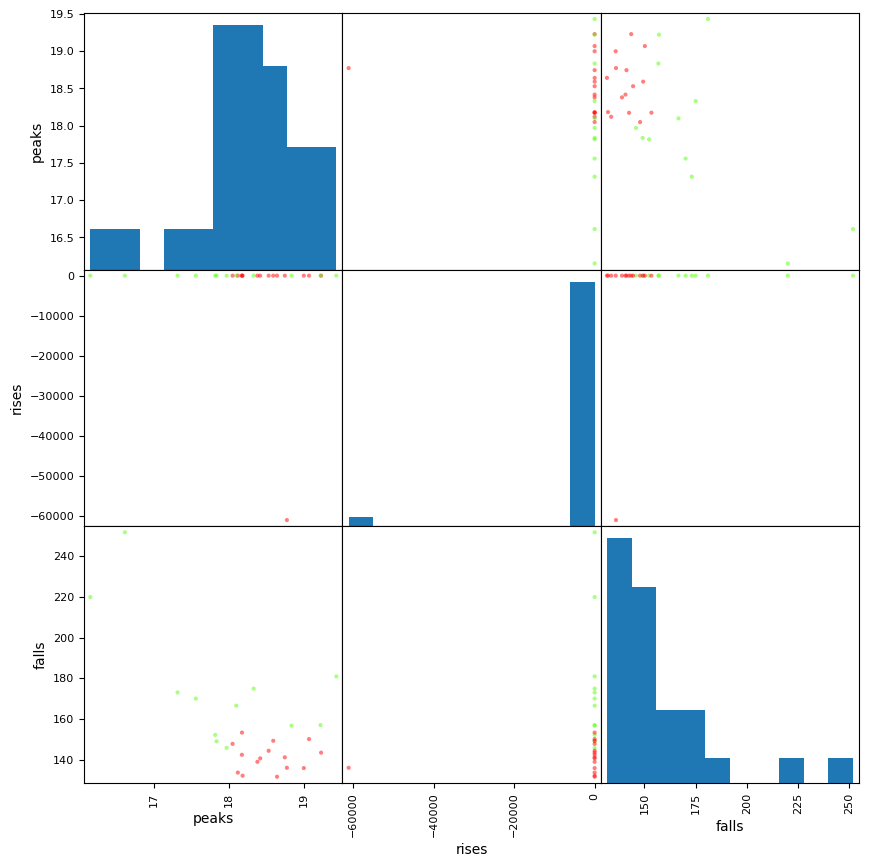

In [72]:
# features = features.drop(index=15)
# label = np.delete(label, 15)
clf = RandomForestClassifier(max_depth=None, random_state=0)
# clf.fit([curve.T, peak], label)
# pred = clf.predict([curve, peak])
predict_clf = cross_val_predict(clf, features, label)

pd.plotting.scatter_matrix(features, figsize=(10,10), c=predict_clf, cmap="prism")

In [73]:
print(f"Accuracy: {np.sum((predict_clf & label))/len(label)}")

Accuracy: 0.3333333333333333
